In [4]:
import os
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
from keras.models import load_model
from tensorflow.keras import utils
from natsort import natsorted

In [2]:
mapping = pd.read_csv('Kaggle/emnist-byclass-mapping.txt',
                      delimiter = ' ', 
                      index_col=0, 
                      header=None, 
                      squeeze=True)
model = load_model('character_recognizer.h5')

In [3]:
filepath = 'G:\\Kuliah\\skripsi\\Project\\Converts to MNIST\\clean\\' # 'resized/'
files = os.listdir(filepath)
files = natsorted(files)

R1CHARDLAWRENCeIHIOSDPR


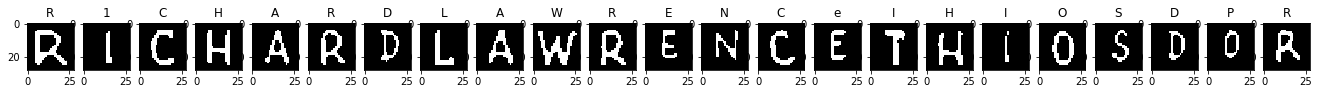

In [24]:
imges = []
preds = []
for filename in files:
    img = cv2.imread(filepath+filename, cv2.IMREAD_GRAYSCALE)
    imges.append(img)
    
    normalized_img = utils.normalize(img, axis=1)
    normalized_img = np.resize(normalized_img, (1, 28, 28, 1))
    
    pred = model.predict(normalized_img)
    letter = chr(mapping[pred.argmax()])
    preds.append(letter)
print(''.join(preds))


columns = len(preds)
rows = 1

fig=plt.figure(figsize=(len(preds), len(preds)))

for i, img, pred in zip(range(1, columns*rows +1), imges, preds):
    fig.add_subplot(rows, columns, i)
    
    plt.imshow(img.reshape(28,28), cmap=plt.cm.gray)
    plt.title(pred)